# DiD se encuentra con las proyecciones locales: LP-DiD

Una política se despliega por los estados en oleadas, su efecto *se acumula
con el tiempo*, y usted quiere la respuesta dinámica completa — no un único
número contaminado. El notebook 10 mostró por qué el estudio de eventos de
efectos fijos en dos vías (TWFE) de libro de texto se rompe bajo adopción
escalonada y cómo lo repara Callaway-Sant'Anna. Esta secuela muestra la
reparación con *proyecciones locales*: **LP-DiD** (Dube, Girardi, Jordà &
Taylor 2023), que conserva el familiar flujo de trabajo de Jordà — una
regresión por horizonte — pero restringe cada comparación a unidades recién
tratadas frente a controles *limpios*. Plantamos un efecto dinámico conocido,
vemos cómo el TWFE ingenuo lo destroza, lo recuperamos con
`puremacro.lp.lp_did`, y confirmamos que LP-DiD, Callaway-Sant'Anna y
Sun-Abraham — tres máquinas distintas — coinciden porque comparten un mismo
principio. Todo se ejecuta en el navegador sobre datos sintéticos.

## El método en ecuaciones

**Planteamiento.** La unidad $i$ adopta un tratamiento absorbente en el tiempo
$G_i$ (nunca, para los controles); $D_{it}=\mathbb{1}\{t \ge G_i\}$ y
$\Delta D_{it}=1$ marca el trimestre del *cambio*. Los efectos pueden ser
dinámicos y heterogéneos entre cohortes.

**El fallo del TWFE.** El estudio de eventos TWFE dinámico regresa $y_{it}$
sobre variables ficticias de tiempo relativo más efectos de unidad y de
tiempo. Bajo adopción escalonada con efectos heterogéneos, cada coeficiente es
una suma ponderada de efectos en *otros* tiempos relativos y cohortes — con
pesos posiblemente negativos — de modo que incluso los *adelantos* recogen
efectos del tratamiento (Sun-Abraham 2021; Goodman-Bacon 2021 para el caso
estático).

**LP-DiD.** Estime una regresión de corte transversal por horizonte $h$:
$$ y_{i,t+h} - y_{i,t-1} \;=\; \beta_h\,\Delta D_{it} \;+\; \delta_t^h \;+\; e_{it}^h, $$
conservando solo (i) observaciones **recién tratadas** ($\Delta D_{it}=1$) y
(ii) **controles limpios**: unidades con $D_{i,t+h}=0$, es decir, aún no
tratadas hasta $t+h$ (nunca tratadas o tratadas más tarde). La diferencia
larga elimina el efecto de unidad; el efecto de período $\delta_t^h$ hace la
diferenciación entre grupos; la restricción muestral prohíbe toda comparación
prohibida con unidades ya tratadas. Los coeficientes de tendencias previas
salen **gratis**: la misma regresión en los adelantos $h = -K,\dots,-2$ (con
controles no tratados hasta $t$) debe dar $\beta_h \approx 0$ bajo tendencias
paralelas; $h=-1$ es el período base.

**Pesos.** El MCO simple ('vw') devuelve un promedio *ponderado por varianza*
de los DiD limpios específicos de cada período — pesos $\propto
n_t\,p_t(1-p_t)$, siempre convexos, el análogo bien comportado de la
ponderación TWFE. Reponderar para que cada observación recién tratada cuente
igual ('equal', peso $n_t^{tr}/n_t^{co}$ en los controles) devuelve el **ATT
igualmente ponderado** entre eventos de tratamiento. Ambos están expuestos en
`lp_did`, junto con los diagnósticos de pesos por período.

**Intuición.** LP-DiD es "Callaway-Sant'Anna, pero sin salir nunca del mundo
LP". Cada truco que usted conoce de las proyecciones locales de Jordà —
regresiones horizonte a horizonte, bandas robustas por conglomerados,
variantes IV, dependencia de estado — se traslada, porque el estimador *es*
una LP: los únicos ingredientes específicos de DiD son el resultado en
diferencia larga y la regla muestral de controles limpios. Esa regla es todo
el partido: el TWFE no se rompe porque los efectos fijos estén mal, sino
porque el MCO fabrica silenciosamente comparaciones en las que una unidad *ya
tratada* — cuyo resultado todavía arrastra su propia dinámica de tratamiento —
hace de "control". Prohíba esas comparaciones y cualquier agregación sensata
de lo que queda es consistente; CS, Sun-Abraham y LP-DiD son solo tres reglas
de agregación sobre los mismos bloques limpios.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.lp import lp_did, LPDiDResult
from puremacro.did import callaway_santanna, sun_abraham

## 1. El fallo, plantado: TWFE con dinámicas heterogéneas

Dos cohortes adoptan en t = 7 y t = 13 (30 unidades cada una; 40 nunca
tratadas). El efecto de la cohorte *temprana* **crece** con el tiempo desde la
adopción ($\tau_E(e)=0.4+0.35e$); el de la *tardía* es plano ($\tau_L = 1.0$).
Hacemos este primer panel **sin ruido**, de modo que cada desviación que vea
más abajo es puro sesgo de especificación — no error muestral. Ambas
regresiones ingenuas se ajustan en línea en unas pocas líneas (demeaning
exacto en dos vías sobre un panel balanceado).

In [2]:
def simulate(cohort_sizes, T, effect, sigma, seed, pre_slope=0.0):
    """Staggered-adoption panel with unit/time FE and known dynamic ATTs."""
    rng = np.random.default_rng(seed)
    lam = rng.standard_normal(T) * 0.3
    rows, uid = [], 0
    for g, m in cohort_sizes.items():
        for _ in range(m):
            a = rng.standard_normal()
            for t in range(1, T + 1):
                on = (g is not None) and (t >= g)
                tau = effect(g, t - g) if on else 0.0
                drift = pre_slope * t if g is not None else 0.0  # trend violation knob
                rows.append({"unit": uid, "time": t,
                             "y": a + lam[t - 1] + drift + tau
                                  + sigma * rng.standard_normal(),
                             "D": float(on),
                             "treat_time": np.nan if g is None else float(g)})
            uid += 1
    return pd.DataFrame(rows)

def two_way_demean(df, cols):
    """Exact TWFE projection for a balanced panel (unit and time means)."""
    out = {}
    for c in cols:
        v = df[c].astype(float)
        out[c] = (v - df.groupby("unit")[c].transform("mean")
                    - df.groupby("time")[c].transform("mean") + v.mean()).to_numpy()
    return out

def naive_event_study(df, leads=range(-4, -1), lags=range(0, 14)):
    """Fully saturated dynamic TWFE event study (no binning tricks needed)."""
    d = df.copy()
    d["e"] = d["time"] - d["treat_time"]
    evts = list(leads) + list(lags)                   # e = -1 omitted (base)
    for e in evts:
        d[f"e{e}"] = (d["e"] == e).astype(float)   # NaN event time compares False
    dm = two_way_demean(d, ["y"] + [f"e{e}" for e in evts])
    X = np.column_stack([dm[f"e{e}"] for e in evts])
    coef, *_ = np.linalg.lstsq(X, dm["y"], rcond=None)
    return dict(zip(evts, coef))

TRUE = lambda g, e: (0.4 + 0.35 * e) if g == 7 else 1.0
SIZES = {7: 30, 13: 30, None: 40}
T = 20
true_path = np.array([(30 * TRUE(7, h) + 30 * TRUE(13, h)) / 60 for h in range(9)])

demo = simulate(SIZES, T, TRUE, sigma=0.0, seed=0)
dm = two_way_demean(demo, ["y", "D"])
beta_twfe = float(dm["D"] @ dm["y"] / (dm["D"] @ dm["D"]))
cell_avg = float(np.mean([TRUE(g, t - g) for g, m in {7: 30, 13: 30}.items()
                          for t in range(g, T + 1) for _ in range(m)]))
naive = naive_event_study(demo)

print(f"static TWFE 'the effect'   = {beta_twfe:+.3f}   "
      f"(true avg over treated cells = {cell_avg:+.3f})")
print(f"naive event-study leads    = " +
      ", ".join(f"e={e}: {naive[e]:+.3f}" for e in (-4, -3, -2)) +
      "   (truth: all exactly 0)")
print(f"naive event-study at e=0   = {naive[0]:+.3f}   (truth {true_path[0]:+.3f})")

assert beta_twfe < cell_avg - 0.6                 # static TWFE badly downward-biased
assert abs(naive[-2]) > 0.10                      # spurious pre-trend from nothing
assert abs(naive[0] - true_path[0]) > 0.20        # impact effect distorted too

static TWFE 'the effect'   = +1.247   (true avg over treated cells = +2.066)
naive event-study leads    = e=-4: -0.101, e=-3: -0.136, e=-2: -0.172   (truth: all exactly 0)
naive event-study at e=0   = +0.441   (truth +0.700)


**Lectura del resultado.** Con *cero* ruido, el TWFE estático reporta +1.25
para una política cuyo verdadero efecto promedio sobre los tratados es +2.07 —
una subestimación del 40% fabricada íntegramente por comparaciones prohibidas
(las unidades tratadas temprano, aún en su senda creciente de efecto, se usan
como "controles" de la cohorte tardía, y su crecimiento se resta). El estudio
de eventos dinámico no rescata nada: está *totalmente saturado* en tiempo
relativo y aun así los adelantos salen entre −0.10 y −0.17 cuando la verdad es
exactamente cero — la heterogeneidad entre cohortes filtra efectos del
tratamiento hacia los coeficientes pre-tratamiento (el resultado de
contaminación de Sun-Abraham), el efecto de impacto se desvía en un tercio, y
un dictaminador que leyera estos adelantos rechazaría tendencias paralelas
*que se cumplen por construcción*.

## 2. LP-DiD: la reparación que no sale del mundo LP

El mismo diseño, ahora con ruido realista ($\sigma = 0.35$). `lp_did` corre
una regresión por horizonte sobre recién tratados vs controles limpios,
reporta tendencias previas para $h=-4..-2$ "gratis", cuenta la muestra
tratada/limpia por horizonte, y agrupa los errores estándar por unidad. El
`weights='equal'` por defecto apunta al ATT igualmente ponderado entre los 60
eventos de adopción.

In [3]:
panel = simulate(SIZES, T, TRUE, sigma=0.35, seed=42)
res = lp_did(panel, "y", "D", "unit", "time", horizons=range(0, 7), pre_window=4)
assert isinstance(res, LPDiDResult)
print(res.summary())
print(res.estimates.round(3).to_string(index=False))

est = res.post.set_index("h")["beta"]
err = np.abs(est.to_numpy() - true_path[:7])
pre_t = res.pretrend["t"].abs().max()
print(f"\nmax |error| vs planted dynamic ATT = {err.max():.3f}")
print(f"max |t| across pre-trends          = {pre_t:.2f}")

assert err.max() < 0.25                            # dynamic path recovered
assert pre_t < 2.5                                 # no false pre-trend alarm
# Clean-control discipline: at h = 6 the late cohort (t=13) would need
# controls untreated through t+6 = 19 -- only the never-treated remain.
assert res.estimates.set_index("h").loc[6, "n_clean"] < \
       res.estimates.set_index("h").loc[0, "n_clean"]

LP-DiD (Dube-Girardi-Jordà-Taylor) result
  weights           : equal
  clean controls    : True
  units / events    : 100 / 60
  post horizons     : 0..6
  pre-trends        : h = -4..-2, max |t| = 1.87
  ATT(h=0)          : +0.6205 (se 0.0684)

 h   beta    se      t     lo     hi  n_treated  n_clean  n_obs  n_periods
-4  0.022 0.077  0.280 -0.106  0.149         60      110    170          2
-3 -0.139 0.074 -1.865 -0.261 -0.016         60      110    170          2
-2 -0.104 0.079 -1.318 -0.234  0.026         60      110    170          2
-1  0.000 0.000    NaN  0.000  0.000         60      110    170          2
 0  0.620 0.068  9.071  0.508  0.733         60      110    170          2
 1  0.836 0.070 11.914  0.720  0.951         60      110    170          2
 2  1.019 0.076 13.376  0.894  1.144         60      110    170          2
 3  1.163 0.077 15.016  1.036  1.290         60      110    170          2
 4  1.278 0.084 15.279  1.140  1.415         60      110    170          2
 5 

**Lectura del resultado.** La senda estimada sube desde ≈ +0.6 en el impacto
hasta ≈ +1.8 en $h=6$, siguiendo el perfil promedio por cohorte plantado
dentro de dos errores estándar en todo punto, y los tres adelantos genuinos
rondan el cero (|t| máx < 2) — el mismo panel en el que el estudio de eventos
TWFE saturado acaba de fallar. Observe las columnas de contabilidad:
`n_clean` cae de 110 a 80 en $h = 6$, porque un control limpio debe seguir
sin tratar hasta $t+h$, y la cohorte tratada más tarde deja de calificar para
los horizontes largos de la cohorte temprana. Esa deserción visible *es* la
identificación: usted puede leer exactamente qué comparaciones produjeron
cada coeficiente — sin caja negra.

### Figura principal — un panel, dos estudios de eventos

TWFE ingenuo (cuadrados huecos) frente a LP-DiD con su banda al 90% por
conglomerados, contra la verdad plantada. Los adelantos ingenuos se hunden
bajo cero y su estimación de impacto es demasiado baja; LP-DiD se asienta
sobre la verdad en cada horizonte.

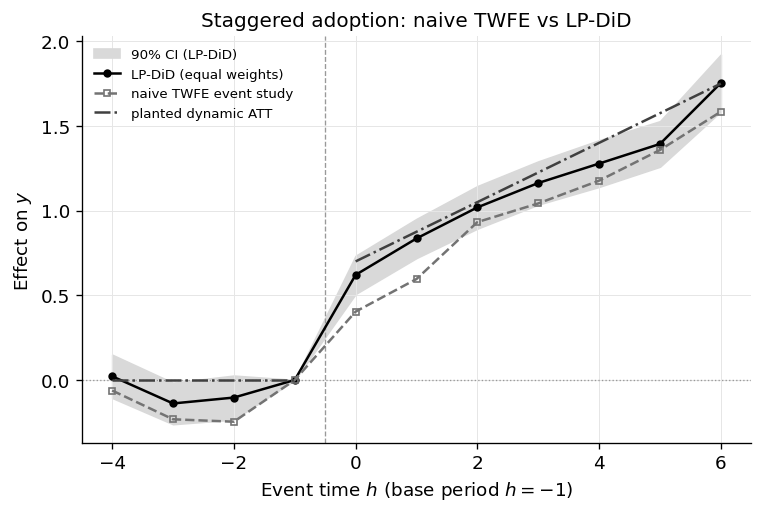

In [4]:
cols = _nbstyle.palette(3)
ev = res.estimates
naive_n = naive_event_study(panel)
e_grid = [e for e in sorted(naive_n) if -4 <= e <= 6] + [-1]
naive_y = [0.0 if e == -1 else naive_n[e] for e in e_grid]

fig, ax = plt.subplots(figsize=(7.2, 4.4))
ax.axhline(0.0, color="0.6", linewidth=0.8, linestyle=":")
ax.axvline(-0.5, color="0.6", linewidth=0.8, linestyle="--")
ax.fill_between(ev["h"], ev["lo"], ev["hi"], color="0.85", label="90% CI (LP-DiD)")
ax.plot(ev["h"], ev["beta"], color=cols[0], marker="o", markersize=4,
        label="LP-DiD (equal weights)")
order = np.argsort(e_grid)
ax.plot(np.array(e_grid)[order], np.array(naive_y)[order], color=cols[1],
        marker="s", markersize=4, markerfacecolor="none", linestyle="--",
        label="naive TWFE event study")
hh = np.arange(0, 7)
ax.plot(hh, true_path[:7], color=cols[2], linestyle="-.",
        label="planted dynamic ATT")
ax.plot(np.arange(-4, 0), np.zeros(4), color=cols[2], linestyle="-.")
ax.set_xlabel("Event time $h$ (base period $h=-1$)")
ax.set_ylabel("Effect on $y$")
ax.set_title("Staggered adoption: naive TWFE vs LP-DiD")
ax.legend(loc="upper left", fontsize=8)
plt.show()

## 3. Tres máquinas, un principio

Callaway-Sant'Anna construye ATTs por grupo-tiempo a partir de bloques 2×2
limpios y los promedia; Sun-Abraham repondera los mismos bloques por las
participaciones de cohorte; LP-DiD llega por regresión, un horizonte a la
vez. Si lo que importa es el principio de comparación limpia — y no la
maquinaria — los tres estudios de eventos deberían quedar uno encima de otro.
Esa es exactamente la lección.

max |LP-DiD - CS| over h=0..6 = 0.032
max |LP-DiD - SA| over h=0..6 = 0.032


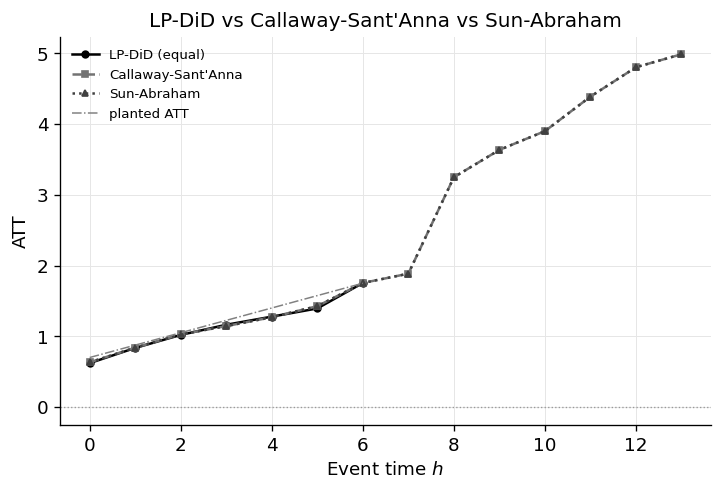

In [5]:
cs = callaway_santanna(panel, unit="unit", time="time", outcome="y",
                       treat_time="treat_time", n_boot=200, alpha=0.10, seed=0)
sa = sun_abraham(panel, unit="unit", time="time", outcome="y",
                 treat_time="treat_time", n_boot=200, alpha=0.10, seed=0)

es_cs = cs.att_event_study.set_index("event_time")
es_sa = sa.att_event_study.set_index("event_time")
gap_cs = max(abs(est.loc[h] - es_cs.loc[h, "att"]) for h in range(7))
gap_sa = max(abs(est.loc[h] - es_sa.loc[h, "att"]) for h in range(7))
print(f"max |LP-DiD - CS| over h=0..6 = {gap_cs:.3f}")
print(f"max |LP-DiD - SA| over h=0..6 = {gap_sa:.3f}")
assert gap_cs < 0.15 and gap_sa < 0.15             # three estimators, same answer

fig, ax = plt.subplots(figsize=(7.0, 4.2))
ax.axhline(0.0, color="0.6", linewidth=0.8, linestyle=":")
ax.plot(est.index, est.to_numpy(), color=cols[0], marker="o", markersize=4,
        label="LP-DiD (equal)")
ax.plot(es_cs.index[es_cs.index >= 0], es_cs.loc[es_cs.index >= 0, "att"],
        color=cols[1], marker="s", markersize=4, linestyle="--",
        label="Callaway-Sant'Anna")
ax.plot(es_sa.index[es_sa.index >= 0], es_sa.loc[es_sa.index >= 0, "att"],
        color=cols[2], marker="^", markersize=4, linestyle=":",
        label="Sun-Abraham")
ax.plot(hh, true_path[:7], color="0.5", linewidth=0.9, linestyle="-.",
        label="planted ATT")
ax.set_xlabel("Event time $h$")
ax.set_ylabel("ATT")
ax.set_title("LP-DiD vs Callaway-Sant'Anna vs Sun-Abraham")
ax.legend(loc="upper left", fontsize=8)
plt.show()

**Lectura del resultado.** Las tres sendas difieren a lo sumo en ≈ 0.03 —
menos de medio error estándar — pese a recorridos de código completamente
distintos: ningún paso de `lp_did` invoca el módulo DiD. La pequeña luz que
queda entre ellas es exactamente la diferencia de agregación anunciada (CS
promedia cohortes por igual, SA y LP-DiD ponderan por tamaño de cohorte, y
LP-DiD agrupa las unidades aún-no-tratadas en los controles mientras esta
implementación de CS usa solo las nunca tratadas). Cuando alguien pregunte
"¿qué estimador de DiD escalonado debo usar?", esta figura es la respuesta:
cualquiera de ellos, *siempre que las comparaciones sean limpias* — elija el
que produzca las salidas que necesita. La ventaja de LP-DiD es todo lo que
viene gratis en el mundo LP: regresiones por horizonte que puede pasarle a
`cum_irf_block_bootstrap`, versiones IV, dependencia de estado, bandas
Driscoll-Kraay.

## 4. Tendencias previas como salida de primera clase

Como los adelantos son solo más horizontes LP, el contraste de tendencias
previas no es un procedimiento aparte — la misma llamada los devuelve, con
los mismos errores estándar por conglomerados. Re-simulamos el panel dando a
las unidades alguna-vez-tratadas una deriva diferencial de +0.18 por período
(una violación genuina de tendencias paralelas) y comparamos los coeficientes
de los adelantos con los del panel limpio.

violated panel  : h=-4: -0.43 (t -3.6), h=-3: -0.27 (t -2.1), h=-2: -0.16 (t -1.3)
clean panel     : h=-4: +0.11 (t +0.9), h=-3: +0.09 (t +0.7), h=-2: +0.02 (t +0.2)


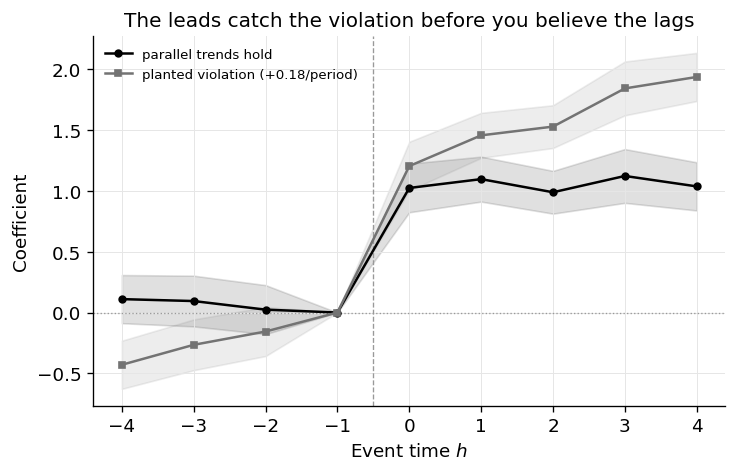

In [6]:
vio = simulate({7: 30, None: 40}, 18, lambda g, e: 1.0, sigma=0.35, seed=9,
               pre_slope=0.18)
cln = simulate({7: 30, None: 40}, 18, lambda g, e: 1.0, sigma=0.35, seed=9,
               pre_slope=0.0)
r_vio = lp_did(vio, "y", "D", "unit", "time", range(0, 5), pre_window=4)
r_cln = lp_did(cln, "y", "D", "unit", "time", range(0, 5), pre_window=4)

pre_v = r_vio.pretrend.set_index("h")
pre_c = r_cln.pretrend.set_index("h")
print("violated panel  :",
      ", ".join(f"h={h}: {pre_v.loc[h, 'beta']:+.2f} (t {pre_v.loc[h, 't']:+.1f})"
                for h in (-4, -3, -2)))
print("clean panel     :",
      ", ".join(f"h={h}: {pre_c.loc[h, 'beta']:+.2f} (t {pre_c.loc[h, 't']:+.1f})"
                for h in (-4, -3, -2)))

assert pre_v.loc[-4, "beta"] < -0.25 and pre_v.loc[-4, "t"] < -3.0
assert pre_c["t"].abs().max() < 2.0

fig, ax = plt.subplots(figsize=(6.8, 4.0))
ax.axhline(0.0, color="0.6", linewidth=0.8, linestyle=":")
ax.axvline(-0.5, color="0.6", linewidth=0.8, linestyle="--")
for r, c, lbl, mk in [(r_cln, cols[0], "parallel trends hold", "o"),
                      (r_vio, cols[1], "planted violation (+0.18/period)", "s")]:
    e = r.estimates
    ax.fill_between(e["h"], e["lo"], e["hi"], color=c, alpha=0.12)
    ax.plot(e["h"], e["beta"], color=c, marker=mk, markersize=4, label=lbl)
ax.set_xlabel("Event time $h$")
ax.set_ylabel("Coefficient")
ax.set_title("The leads catch the violation before you believe the lags")
ax.legend(loc="upper left", fontsize=8)
plt.show()

**Lectura del resultado.** En el panel violado los adelantos se abren en
abanico hacia abajo — $\beta_{-4} \approx -0.43$ con $t \approx -3.6$, cerca
de la predicción mecánica $-0.18 \times 3 = -0.54$ (cada adelanto adicional
acumula un período más de deriva diferencial; el signo es negativo porque el
*período base* $t-1$ del grupo tratado está más alto, no más bajo, que su
pasado). Los adelantos del panel limpio se mantienen planos con |t| < 1. Y
fíjese en lo que la violación le hace al "efecto": los coeficientes post del
panel violado están inflados por la misma deriva — un rechazo de tendencias
previas no es un formalismo, le está diciendo que los rezagos absorben
tendencia, no tratamiento.

**Dónde usaría esto.** El hábitat natural de LP-DiD son exactamente los
paneles a los que apunta este paquete. Adopciones de políticas estatales:
cambios de salario mínimo, extensiones del seguro de desempleo, leyes de
derecho al trabajo — escalonadas por construcción, con efectos que se
incorporan gradualmente (el escenario de los re-análisis del salario mínimo
que motivaron la literatura de controles limpios). Estudios de eventos de
incertidumbre a nivel estatal: trate a un estado como "cambiando" cuando lo
golpea por primera vez una oleada de cierres de plantas, un pico de avisos
WARN o un shock de política comercial, y rastree el empleo y la participación
en los trimestres siguientes — el tipo de análisis de mercados laborales
locales que sostienen los descargadores y paneles de este paquete, donde la misma
disciplina de controles limpios separa la respuesta de un estado a su propio
shock de la dinámica de los estados golpeados antes. Y como LP-DiD *es* una
proyección local, las extensiones que buscaría en ese contexto — multiplicadores
acumulados con bandas de bootstrap por entidad, instrumentar el cambio,
respuestas dependientes del estado — son las herramientas LP que ya tiene, no
estimadores nuevos.

## Su turno — vea a las dos ponderaciones discrepar

`weights='vw'` (MCO simple) pondera cada período de adopción por
$n_t p_t(1-p_t)$ — le encantan los períodos con una mezcla equilibrada de
tratados y controles. `weights='equal'` da a cada *evento* de adopción la
misma voz. Con una cohorte temprana grande (30 unidades, $\tau = 0.5$) y una
cohorte tardía pequeña (5 unidades, $\tau$ = su elección), las dos respuestas
deben separarse siempre que las cohortes de verdad difieran. El panel de abajo
no tiene ruido, así que las estimaciones son exactas y la brecha es pura
ponderación.

In [7]:
# ← Change this: the small late cohort's treatment effect (try 0.5, -1.0, 4.0).
TAU_SMALL_YOU = 2.0

TAU_BIG = 0.5
mini = simulate({6: 30, 12: 5, None: 10}, 20,
                lambda g, e: TAU_BIG if g == 6 else TAU_SMALL_YOU,
                sigma=0.0, seed=1)
r_eq = lp_did(mini, "y", "D", "unit", "time", range(0, 5), pre_window=0)
r_vw = lp_did(mini, "y", "D", "unit", "time", range(0, 5), pre_window=0,
              weights="vw")
eq0 = float(r_eq.post.loc[r_eq.post["h"] == 0, "beta"].iloc[0])
vw0 = float(r_vw.post.loc[r_vw.post["h"] == 0, "beta"].iloc[0])
print(f"equal-weighted ATT(0) = {eq0:+.3f}   variance-weighted ATT(0) = {vw0:+.3f}")
print(r_eq.group_weights[r_eq.group_weights["h"] == 0].round(3).to_string(index=False))

# The event shares are 30/35 vs 5/35, but the vw period weights are 0.75/0.25:
# vw tilts TOWARD the small cohort here (its period has the better mix), so the
# gap's sign follows the small cohort's effect relative to the big one's.
if abs(TAU_SMALL_YOU - TAU_BIG) > 1e-9:
    assert np.sign(vw0 - eq0) == np.sign(TAU_SMALL_YOU - TAU_BIG), (eq0, vw0)
else:
    assert abs(vw0 - eq0) < 1e-8

equal-weighted ATT(0) = +0.714   variance-weighted ATT(0) = +0.875
 h  time  n_treated  n_clean  w_vw  w_equal
 0     6         30       15  0.75    0.857
 0    12          5       10  0.25    0.143


**Ejercicios.** (1) *Básico*: fije `TAU_SMALL_YOU = 0.5` (efectos homogéneos)
y confirme que las dos ponderaciones colapsan al mismo número — ponderar solo
importa cuando hay heterogeneidad que ponderar. (2) *Intermedio*: fíjelo en
`-1.0` y prediga, antes de ejecutar, cuál estimador reporta el ATT más
negativo; verifíquelo contra las participaciones `w_vw` / `w_equal`
impresas. (3) *Avanzado*: elimine el grupo nunca tratado de `SIZES` en la
sección 2 (use `{7: 30, 13: 30}`) y vuelva a ejecutar `lp_did` con
`horizons=range(0, 9)` — lea la columna `n_clean` mientras los horizontes
tardíos se quedan sin controles limpios y los más largos devuelven `NaN`;
luego explique por qué el TWFE ingenuo de la sección 1 *nunca* le advierte de
esto.

**¿Qué tan completo es esto?** `puremacro.lp.lp_did` devuelve un
`LPDiDResult` congelado con las estimaciones, los conteos tratados/limpios
por horizonte y los diagnósticos de pesos por período de DGJT
(`group_weights`). Sus primos DiD viven en `puremacro.did` —
`callaway_santanna`, `sun_abraham`, el estimador de imputación
`borusyak_jaravel_spiess`, `cdh_did` y el DiD sintético — todos compartiendo
el formato de panel `(unit, time, outcome, treat_time)` usado aquí (el
notebook 10 es la precuela). Del lado LP, `panel_lp` / `panel_lp_dk` son los
caballos de batalla para shocks continuos, `lp_iv` instrumenta el shock, y
`puremacro.inference.lp_block_bootstrap` convierte cualquier senda por
horizonte en bandas de IRF acumulada vía bootstrap por entidad (el notebook
07 cubre los fundamentos de LP).